In [1]:
using DPNeurifyFV, LazySets, JuMP, LinearAlgebra, Gurobi, Plots, DataStructures
const DP = DPNeurifyFV
const L = DP.LSTMRelaxation

Academic license - for non-commercial use only - expires 2024-11-27
precompiling...
node input_Sub: sub constant

parsing flatten :-)
parsing Matmul with input :-)
node Operation_1_Add: add constant

parsing ReLU :-)
parsing Matmul with input :-)
node Operation_2_Add: add constant

parsing ReLU :-)
parsing Matmul with input :-)
node Operation_3_Add: add constant

parsing ReLU :-)
parsing Matmul with input :-)
node Operation_4_Add: add constant

parsing ReLU :-)
parsing Matmul with input :-)
node Operation_5_Add: add constant

parsing ReLU :-)
parsing Matmul with input :-)
node Operation_6_Add: add constant

parsing ReLU :-)
parsing Matmul with input :-)
node linear_7_Add: add constant

Network inputs: ["input"]
Network outputs: ["linear_7_Add"]
Constructing the whole NN -- yay -- :-)
inputs: ["input"]
outputs: ["linear_7_Add"]
input_shape = Any[1, 1, 1, 5], output_shape = Any[1, 5]


/home/philipp/.julia/conda/3/lib/python3.10/site-packages/vnnlib/parser.py:213: UserWarning: literal negation does not strictly follow SMT-LIB
  warnings.warn("literal negation does not strictly follow SMT-LIB")


Warning! Output constraints have to be polytopes, found b with size (1, 1) - trying vec(b)
Checking if polytope can be reached


┌ Warning: Layer with Float32 parameters got Float64 input.
│   The input will be converted, but any earlier layers may be very slow.
│   layer = Dense(5 => 50)      # 300 parameters
│   summary(x) = "5×6 Matrix{Float64}"
└ @ Flux ~/.julia/packages/Flux/jgpVj/src/layers/stateless.jl:60


i: 1 - [-4.01316499710083, 2269.2729241943107], 7.371348857879639 sec
i: 2 - [-4.01316499710083, 1122.462314027753], 11.3225998878479 sec
i: 3 - [-4.01316499710083, 1095.465432296466], 11.331523895263672 sec
Steps: 3 - [-1030.3663799624544, 4.01316499710083] -> inconclusive
Academic license - for non-commercial use only - expires 2024-11-27
Academic license - for non-commercial use only - expires 2024-11-27
Academic license - for non-commercial use only - expires 2024-11-27


DPNeurifyFV.LSTMRelaxation

In [2]:
z = Zonotope(zeros(2), randn(2, 4))

Zonotope{Float64, Vector{Float64}, Matrix{Float64}}([0.0, 0.0], [1.5388240351462052 0.1955844244254928 -0.058600095065259684 -0.7957697985146835; -0.7191219028212421 0.035468831160881543 -1.3585467433412224 -0.40881104626979003])

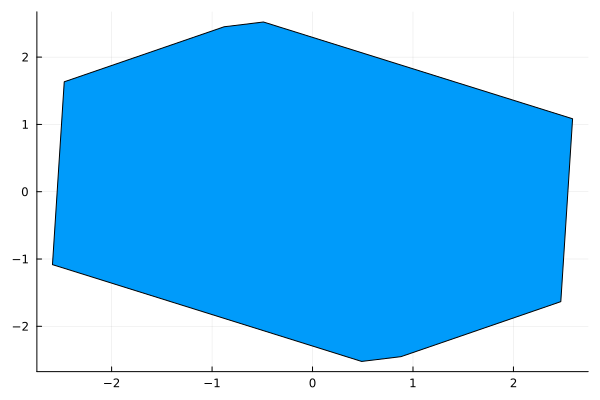

In [3]:
plot(z)

# Interval Arithmetic Overapproximations

Using interval arithmetic

$max_{\lambda \in [0, 1]} \sigma((1 - \lambda) * x_0 + \lambda x_1)*((1 - \lambda) * y_0 + \lambda y_1) - (ax + by + c)$

$\max_{x, y \in [xl, xu] \times [yl, yu]} \sigma(x)*y - (ax + bx + c)$

In [4]:
v = DP.vertices_list_2d_zonotope(z)

2×9 Matrix{Float64}:
  0.48887   0.880039   2.47158  2.58878  …  -2.47158  -2.58878   0.48887
 -2.52195  -2.45101   -1.63339  1.0837       1.63339  -1.0837   -2.52195

In [5]:
v = DP.vertices_list_2d_zonotope(z)
α = v[1,1:end-1] - v[1,2:end]  # α = xᵢ - xᵢ₊₁
β = v[1,2:end]

8-element Vector{Float64}:
  0.8800385659917547
  2.4715781630211224
  2.5887783531516413
 -0.4888697171407692
 -0.8800385659917547
 -2.4715781630211224
 -2.5887783531516413
  0.4888697171407692

## Linear Interpolation

In [6]:
"""
Interval overapproximation of (1 - λ)*x0 + λ*x1 with λ ∈ [λl, λu] and constants x0, x1
"""
function line_interval_overapprox(x0, x1, λl, λu)
    if x0 >= 0 && x1 >= 0
        l = x0 - x0*λu + x1*λl
        u = x0 - x0*λl + x1*λu
    elseif x0 < 0 && x1 >= 0
        l = x0 - x0*λl + x1*λl
        u = x0 - x0*λu + x1*λu
    elseif x0 >= 0 && x1 < 0
        l = x0 - x0*λu + x1*λu
        u = x0 - x0*λl + x1*λl
    else
        l = x0 - x0*λl + x1*λu
        u = x0 - x0*λu + x1*λl
    end

    return l, u    
end

line_interval_overapprox

In [7]:
x0 = randn()
x1 = randn()

lx, ux = line_interval_overapprox(x0, x1, 0., 1.)
@show lx, ux

λs = 0.:0.01:1.
xs = (1 .- λs) .* x0 .+ λs .* x1

@show minimum(xs)
@show maximum(xs)

@show lx <= minimum(xs)
@show ux >= maximum(xs)

(lx, ux) = (0.0, 1.0344218055231824)
minimum(xs) = 0.2859027603823169
maximum(xs) = 0.7485190451408654
lx <= minimum(xs) = true
ux >= maximum(xs) = true


true

## LSTM Activation Functions

In [8]:
function interval_σy(x₀, x₁, y₀, y₁, λl, λu)
    lx, ux = line_interval_overapprox(x₀, x₁, λl, λu)
    ly, uy = line_interval_overapprox(y₀, y₁, λl, λu)
    
    # Sigmoid is monotonic
    lσ = L.σ(lx) 
    uσ = L.σ(ux)

    lσy = min(lσ * ly, lσ * uy, uσ * ly, uσ * uy)
    uσy = max(lσ * ly, lσ * uy, uσ * ly, uσ * uy)

    return lσy, uσy
end

interval_σy (generic function with 1 method)

In [9]:
function interval_σtanh(x₀, x₁, y₀, y₁, λl, λu)
    lx, ux = line_interval_overapprox(x₀, x₁, λl, λu)
    ly, uy = line_interval_overapprox(y₀, y₁, λl, λu)

    lσ = L.σ(lx) 
    uσ = L.σ(ux)
    ltanh = tanh(lx)
    utanh = tanh(ux)

    lσy = min(lσ * ltanh, lσ * utanh, uσ * ltanh, uσ * utanh)
    uσy = max(lσ * ltanh, lσ * utanh, uσ * ltanh, uσ * utanh)
    
    return lσy, uσy
end

interval_σtanh (generic function with 1 method)

In [10]:
n = 1000
x₀ = randn(n)
x₁ = randn(n)
y₀ = randn(n)
y₁ = randn(n)

λ = rand(n)
λl = λ .- max.(0., 0.1)
λu = λ 

x = (1 .- λ) .* x₀ .+ λ .* x₁
y = (1 .- λ) .* y₀ .+ λ .* y₁

z_true = L.σ.(x) .* y
z_bounds = interval_σy.(x₀, x₁, y₀, y₁, 0, 1)
z_low = first.(z_bounds)
z_up  = last.(z_bounds)

@show all(z_low .<= z_true)
@show all(z_true .<= z_up)

all(z_low .<= z_true) = true
all(z_true .<= z_up) = true


true

x₀ = -0.751529448835319, x₁ = 0.7505514591708601
y₀ = -0.7411844223077345, y₁ = 2.6474811463637127


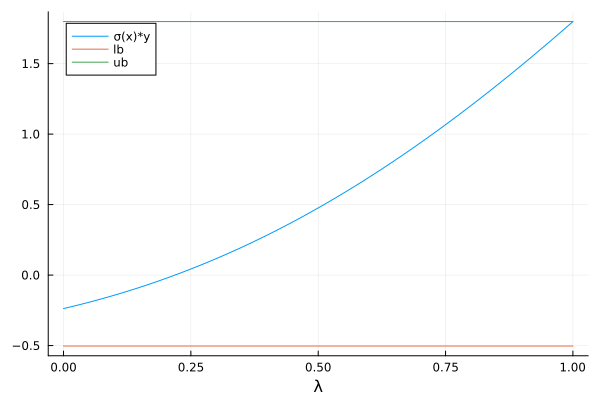

In [11]:
x₀ = randn()
x₁ = randn()
y₀ = randn()
y₁ = randn()
λl = 0.
λu = 1.

println("x₀ = ", x₀, ", x₁ = ", x₁)
println("y₀ = ", y₀, ", y₁ = ", y₁)

f = λ -> L.σ((1 - λ)*x₀ + λ*x₁) * ((1 - λ)*y₀ + λ*y₁)

fl, fu = interval_σy(x₀, x₁, y₀, y₁, λl, λu)

λs = λl:0.01:λu
plot(λs, f.(λs), label="σ(x)*y", xlabel="λ")
plot!([λl, λu], [fl, fl], label="lb")
plot!([λl, λu], [fu, fu], label="ub")

Want to bound $\sigma(x)*y - (ax + by + c)$

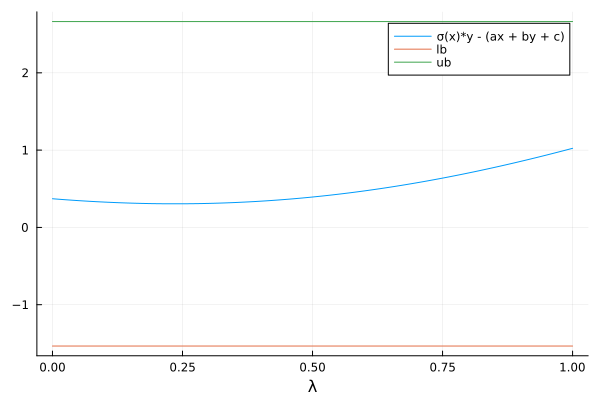

In [12]:
a = randn()
b = randn()
c = randn()
lx, ux = line_interval_overapprox(x₀, x₁, λl, λu)
ly, uy = line_interval_overapprox(y₀, y₁, λl, λu)

fl, fu = interval_σy(x₀, x₁, y₀, y₁, λl, λu)
lin_l = a*ifelse(a >= 0, lx, ux) + b*ifelse(b >= 0, ly, uy) + c
lin_u = a*ifelse(a >= 0, ux, lx) + b*ifelse(b >= 0, uy, ly) + c

outl = fl - lin_u
outu = fu - lin_l

g = λ -> begin
    x = (1 - λ)*x₀ + λ*x₁
    y = (1 - λ)*y₀ + λ*y₁
    L.σ(x) * y - (a*x + b*y + c)
end

λs = λl:0.01:λu
plot(λs, g.(λs), label="σ(x)*y - (ax + by + c)", xlabel="λ")
plot!([λl, λu], [outl, outl], label="lb")
plot!([λl, λu], [outu, outu], label="ub")

## Activation Function with Linear Relaxation

In [13]:
function interval_σy_lin(x₀, x₁, y₀, y₁, λl, λu, a, b, c)
    lx, ux = line_interval_overapprox(x₀, x₁, λl, λu)
    ly, uy = line_interval_overapprox(y₀, y₁, λl, λu)

    fl, fu = interval_σy(x₀, x₁, y₀, y₁, λl, λu)
    lin_l = a*ifelse(a >= 0, lx, ux) + b*ifelse(b >= 0, ly, uy) + c
    lin_u = a*ifelse(a >= 0, ux, lx) + b*ifelse(b >= 0, uy, ly) + c

    outl = fl - lin_u
    outu = fu - lin_l

    return outl, outu
end

interval_σy_lin (generic function with 1 method)

In [14]:
function interval_σtanh_lin(x₀, x₁, y₀, y₁, λl, λu, a, b, c)
    lx, ux = line_interval_overapprox(x₀, x₁, λl, λu)
    ly, uy = line_interval_overapprox(y₀, y₁, λl, λu)

    fl, fu = interval_σtanh(x₀, x₁, y₀, y₁, λl, λu)
    lin_l = a*ifelse(a >= 0, lx, ux) + b*ifelse(b >= 0, ly, uy) + c
    lin_u = a*ifelse(a >= 0, ux, lx) + b*ifelse(b >= 0, uy, ly) + c

    outl = fl - lin_u
    outu = fu - lin_l

    return outl, outu
end

interval_σtanh_lin (generic function with 1 method)

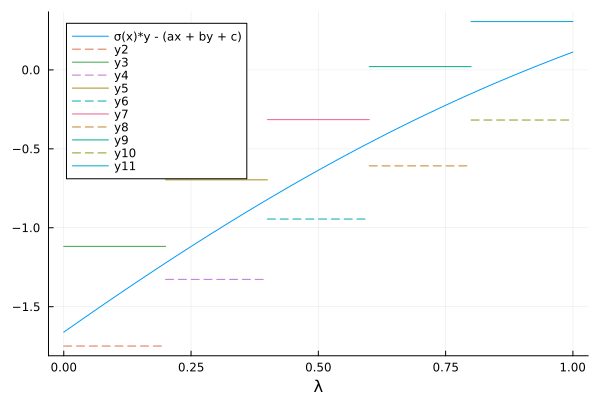

In [15]:
n_sub = 5  # sub-intervals
x₀ = randn()
x₁ = randn()
y₀ = randn()
y₁ = randn()
λl = 0.
λu = 1.

a = randn()
b = randn()
c = randn()

outl, outu = interval_σy_lin(x₀, x₁, y₀, y₁, λl, λu, a, b, c)

g = λ -> begin
    x = (1 - λ)*x₀ + λ*x₁
    y = (1 - λ)*y₀ + λ*y₁
    L.σ(x) * y - (a*x + b*y + c)
end


λs = λl:0.01:λu
plot(λs, g.(λs), label="σ(x)*y - (ax + by + c)", xlabel="λ")

subintervals = range(0., 1., length=n_sub+1)
for (lsub, usub) in zip(subintervals[1:end-1], subintervals[2:end])
    outl, outu = interval_σy_lin(x₀, x₁, y₀, y₁, lsub, usub, a, b, c)

    plot!([lsub, usub], [outl, outl], linestyle=:dash)
    plot!([lsub, usub], [outu, outu], linestyle=:solid)
end

current()

# Branch&Bound

In [16]:
"""
Generic branch and bound implementation for maximizing function.

args:
    init_domains - list of initial domains 
    eval_f - function mapping domain to a concrete output value of the function over that domain
    approx_f - function mapping domain to a valid upper bound of the function over that domain
    split_f - function splitting a domain into 2 parts

kwargs:
    max_steps - maximum number of steps 
    optimality_gap - distance between best concrete value and upper bound
"""
function generic_bab(init_domains, eval_f, approx_f, split_f; max_steps=10, optimality_gap=1e-2, printing=false)
    queue = PriorityQueue(Base.Order.Reverse)

    yl = -Inf
    yu = Inf
    for dom in init_domains
        y = eval_f(dom)
        yl = max(y, yl)

        yu = approx_f(dom)
        enqueue!(queue, dom, yu)

        printing && println("enqueuing ", [y, yu])
    end

    for i in 1:max_steps
        dom, yu = peek(queue)

        if yu - yl <= optimality_gap
            printing && println("Found optimal value ∈ ", [yl, yu])
            return yu
        end
    
        dequeue!(queue)
    
        printing && println(i, ": max_λ ∈ ", [yl, yu])
    
        dom1, dom2 = split_f(dom)
        yu1 = approx_f(dom1)
        yu2 = approx_f(dom2)

        yl1 = eval_f(dom1)
        yl2 = eval_f(dom2)
        yl = max(yl, yl1, yl2)
    
        yu1 > yl && enqueue!(queue, dom1, yu1)
        yu2 > yl && enqueue!(queue, dom2, yu2)
    end
    
    return yu
end

generic_bab

In [17]:
function generic_bab(init_domains, eval_f, approx_f, split_f, maximize; max_steps=10, optimality_gap=1e-2, printing=false)
    eval_fun = eval_f
    approx_fun = approx_f
    if !maximize 
        eval_fun = dom -> -approx_f(dom) # -eval_f(dom)
        approx_fun = dom -> -eval_f(dom) # -approx_f(dom)
    end

    yu = generic_bab(init_domains, eval_fun, approx_fun, split_f; max_steps=max_steps, optimality_gap=optimality_gap, printing=printing)
    
    return maximize ? yu : -yu
end

generic_bab (generic function with 2 methods)

## Specialized to Zonotope Boundary

Since the zonotope's border consists of many lines, we need to store their start and end points and $\lambda$ values individually

In [18]:
eval_f = dom -> begin
    λl, λu, x₀, x₁, y₀, y₁ = dom
    λ = 0.5 * (λl + λu)
    x = (1 - λ)*x₀ + λ*x₁
    y = (1 - λ)*y₀ + λ*y₁
    L.σ(x) * y - (a*x + b*y + c)
end

approx_f = dom -> begin
    λl, λu, x₀, x₁, y₀, y₁ = dom
    l, u = interval_σy_lin(x₀, x₁, y₀, y₁, λl, λu, a, b, c)
    u
end

split_f = dom -> begin
    λl, λu, x₀, x₁, y₀, y₁ = dom
    λ_mid = 0.5 * (λl + λu)
    λl1 = λl
    λu1 = λ_mid
    λl2 = λ_mid
    λu2 = λu
    return (λl1, λu1, x₀, x₁, y₀, y₁), (λl2, λu2, x₀, x₁, y₀, y₁)
end

#27 (generic function with 1 method)

In [19]:
function construct_initial_domains(z::Zonotope)
    @assert dim(z) == 2 "Can only construct domains for 2d zonotopes, found dim(z) == $(dim(z))"

    v = DP.vertices_list_2d_zonotope(z)
    n_vertices = size(v, 2) - 1
    x0s = zeros(n_vertices)
    x1s = zeros(n_vertices)
    y0s = zeros(n_vertices)
    y1s = zeros(n_vertices)

    for i in 1:size(v, 2) - 1
        x0s[i] = v[1,i]
        x1s[i] = v[1,i+1]
        y0s[i] = v[2,i]
        y1s[i] = v[2,i+1]
    end

    initial_domains = [(0., 1., x₀, x₁, y₀, y₁) for (x₀, x₁, y₀, y₁) in zip(x0s, x1s, y0s, y1s)]
end

construct_initial_domains (generic function with 1 method)

In [35]:
initial_domains = construct_initial_domains(z)

8-element Vector{NTuple{6, Float64}}:
 (0.0, 1.0, 0.4888697171407692, 0.8800385659917547, -2.521948523593136, -2.451010861271373)
 (0.0, 1.0, 0.8800385659917547, 2.4715781630211224, -2.451010861271373, -1.633388768731793)
 (0.0, 1.0, 2.4715781630211224, 2.5887783531516413, -1.633388768731793, 1.0837047179506518)
 (0.0, 1.0, 2.5887783531516413, -0.4888697171407692, 1.0837047179506518, 2.521948523593136)
 (0.0, 1.0, -0.4888697171407692, -0.8800385659917547, 2.521948523593136, 2.451010861271373)
 (0.0, 1.0, -0.8800385659917547, -2.4715781630211224, 2.451010861271373, 1.633388768731793)
 (0.0, 1.0, -2.4715781630211224, -2.5887783531516413, 1.633388768731793, -1.0837047179506518)
 (0.0, 1.0, -2.5887783531516413, 0.4888697171407692, -1.0837047179506518, -2.521948523593136)

In [36]:
bab_ub = generic_bab(initial_domains, eval_f, approx_f, split_f, max_steps=10, optimality_gap=1e-2, printing=true)

enqueuing [-0.32574505297297085, 2.570337634727777]
enqueuing [-0.6152864918958185, 2.126057757297105]
enqueuing [-0.03328812102326095, 1.9774261136801736]
enqueuing [0.51791752523086, 3.4376053656523906]
enqueuing [-0.32574505297297074, 2.570337634727777]
enqueuing [-0.6152864918958185, 2.126057757297105]
enqueuing [-0.03328812102326095, 1.4424046856367445]
enqueuing [0.5179175252308599, 1.886684563067416]
1: max_λ ∈ [0.51791752523086, 3.4376053656523906]
2: max_λ ∈ [0.6041408916312007, 2.570337634727777]
3: max_λ ∈ [0.6041408916312007, 2.570337634727777]
4: max_λ ∈ [0.6041408916312007, 2.126057757297105]
5: max_λ ∈ [0.6041408916312007, 2.126057757297105]
6: max_λ ∈ [0.6041408916312007, 1.993801791108043]
7: max_λ ∈ [0.6041408916312007, 1.9774261136801736]
8: max_λ ∈ [0.6041408916312007, 1.886684563067416]
9: max_λ ∈ [0.6041408916312007, 1.7229307247360763]
10: max_λ ∈ [0.6041408916312007, 1.4424046856367445]


1.4424046856367445

In [37]:
bab_lb = generic_bab(initial_domains, eval_f, approx_f, split_f, false, max_steps=10, optimality_gap=1e-2, printing=true)

enqueuing [-2.570337634727777, 0.32574505297297085]
enqueuing [-2.126057757297105, 0.6152864918958185]
enqueuing [-1.9774261136801736, 0.03328812102326095]
enqueuing [-3.4376053656523906, -0.51791752523086]
enqueuing [-2.570337634727777, 0.32574505297297074]
enqueuing [-2.126057757297105, 0.6152864918958185]
enqueuing [-1.4424046856367445, 0.03328812102326095]
enqueuing [-1.886684563067416, -0.5179175252308599]
1: max_λ ∈ [-1.4424046856367445, 0.6152864918958185]
2: max_λ ∈ [-0.8805055749020406, 0.6297941300648955]
3: max_λ ∈ [-0.14780793624525534, 0.6281346141919961]
4: max_λ ∈ [0.23884709246828972, 0.6302652831542073]
5: max_λ ∈ [0.43427694952359497, 0.6303428460418636]
6: max_λ ∈ [0.5320970526692732, 0.6303838513405797]
7: max_λ ∈ [0.5812256560679128, 0.6303831069792869]
8: max_λ ∈ [0.6057943716924483, 0.6303884422429451]
9: max_λ ∈ [0.6180892186903457, 0.6303873905048742]
Found optimal value ∈ [0.624237610462846, 0.6303882269342407]


-0.6303882269342407

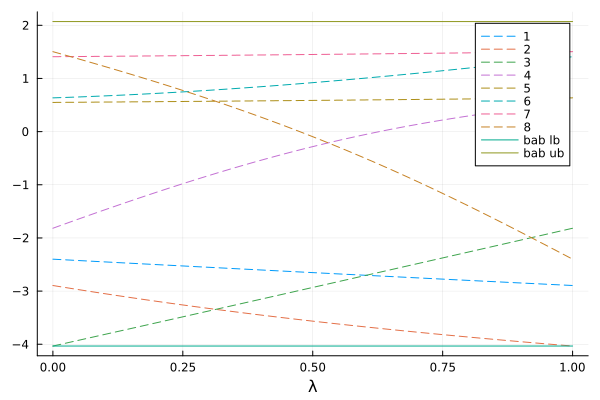

In [23]:
plot(xlabel="λ")
for (i, dom) in enumerate(initial_domains)
    λl, λu, x₀, x₁, y₀, y₁ = dom
    g = λ -> begin
        x = (1 - λ)*x₀ + λ*x₁
        y = (1 - λ)*y₀ + λ*y₁
        L.σ(x) * y - (a*x + b*y + c)
    end

    λs = λl:0.01:λu
    plot!(λs, g.(λs), label="$i", linestyle=:dash)
end

plot!([0., 1.], [bab_lb, bab_lb], label="bab lb")
plot!([0., 1.], [bab_ub, bab_ub], label="bab ub")

In [24]:
function get_relaxation_σy_zono(z; n_samples=100, max_steps=100, optimality_gap=1e-2, printing=false)
    # no extrema in interior for σ(x)y
    v = DP.vertices_list_2d_zonotope(z)

    xs = v[1,1:end-1]
    ys = v[2,1:end-1]
    X = [xs ys ones(size(v, 2)-1)]
    y = L.σ.(xs) .* ys

    a, b, c = L.linear_approximation_lp(X, y)

    initial_domains = construct_initial_domains(z)

    # define functions here because we need fixed a, b, c
    eval_f = dom -> begin
        λl, λu, x₀, x₁, y₀, y₁ = dom
        λ = 0.5 * (λl + λu)
        x = (1 - λ)*x₀ + λ*x₁
        y = (1 - λ)*y₀ + λ*y₁
        L.σ(x) * y - (a*x + b*y + c)
    end

    approx_f = dom -> begin
        λl, λu, x₀, x₁, y₀, y₁ = dom
        l, u = interval_σy_lin(x₀, x₁, y₀, y₁, λl, λu, a, b, c)
        u
    end

    split_f = dom -> begin
        λl, λu, x₀, x₁, y₀, y₁ = dom
        λ_mid = 0.5 * (λl + λu)
        λl1 = λl
        λu1 = λ_mid
        λl2 = λ_mid
        λu2 = λu
        return (λl1, λu1, x₀, x₁, y₀, y₁), (λl2, λu2, x₀, x₁, y₀, y₁)
    end

    ϵₗ = generic_bab(initial_domains, eval_f, approx_f, split_f, false, max_steps=max_steps, optimality_gap=optimality_gap, printing=printing)
    ϵᵤ = generic_bab(initial_domains, eval_f, approx_f, split_f, max_steps=max_steps, optimality_gap=optimality_gap, printing=printing)

    c += 0.5 * (ϵₗ + ϵᵤ)
    ϵ = 0.5 * (ϵᵤ - ϵₗ)

    return a, b, c, ϵ
end

get_relaxation_σy_zono (generic function with 1 method)

In [25]:
H = overapproximate(z, Hyperrectangle)
lx, ly = low(H)
ux, uy = high(H)

L.get_relaxation_σ_y(lx, ux, ly, uy)

(0.0, 0.5, 0.0, 1.0847805283168017)

In [26]:
get_relaxation_σy_zono(z)

(0.0, 0.5, -0.08385794229552224, 0.6303873905048745)

In [27]:
z.generators

2×4 Matrix{Float64}:
  1.53882   0.195584   -0.0586001  -0.79577
 -0.719122  0.0354688  -1.35855    -0.408811

In [34]:
a, b, c, ϵ = get_relaxation_σy_zono(z)

l = Inf
u = -Inf
for i in 1:100
    g = 2 .* rand(ngens(z)) .- 1
    x, y = z.generators * g + z.center

    err = L.σ(x)*y - (a*x + b*y + c)
    l = min(l, err)
    u = max(u, err)
end

@show l
@show u

l = -0.48602517734905615
u = 0.4614540329233866


0.4614540329233866

In [33]:
x

4-element Vector{Float64}:
  0.5625919388667495
  0.7457315228850621
  0.18938221086469031
 -0.40059706502482095